# B 站每周必看栏目数据分析

> **课程**:数据挖掘技术与应用 - 期末考核
> **任务**: 回归任务 - 预测视频播放量 (log view)
> **数据**: ~14000 条 B 站每周必看视频
> **方法**: 6 个基线模型对比 (Linear / DT / RF / AdaBoost / XGBoost / LightGBM)

---

## 一、问题描述

### 1.1 问题背景
B 站"每周必看"是平台重要栏目,每周精选 8 个优质视频。本项目基于该栏目 ~14000 条历史视频数据,探究影响视频播放量的关键因素,并构建预测模型。

**研究问题**: 基于视频的元数据(时长、分区、UP主信息、推荐理由等),能否预测其播放量?

### 1.2 数据准备
- **来源**: B 站官方 API 抓取的 376 期每周必看数据
- **规模**: 清洗后 ~14000 条有效记录
- **字段**: 视频元数据 / 互动数据 / UP主 / 栏目 / 视觉 等 7 大类

### 1.3 方法
- 6 个回归模型: Linear Regression, Decision Tree, Random Forest, AdaBoost, XGBoost, LightGBM
- 5-Fold 交叉验证
- 评估指标: MAE, RMSE, R²

### 1.4 预期结果
- 找出影响播放量的关键特征
- 对比 6 个模型性能
- 给出业务洞察

## 二、项目实现

### 2.1 准备数据

**重要**: 把你的 376 期 JSON 文件放到 `data/raw/` 目录(与本 notebook 同级的 `data/raw/`)。

目录结构应该是:
```
bilibili-mining/
├── bilibili_mining.ipynb   ← 本文件
├── data/
│   └── raw/                ← 放你的 JSON 文件
└── figures/                ← 自动生成
```


In [1]:
# ============================================================
# 1. 加载原始数据
# ============================================================
import json
import time
import warnings
from pathlib import Path

import jieba.analyse
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

warnings.filterwarnings('ignore')

# ---- 配置 ----
RAW_DIR = Path('./data/raw')                # 你的 JSON 所在目录
PROCESSED_DIR = Path('./data/processed')
FIG_DIR = Path('./figures/pandas')
for d in (PROCESSED_DIR, FIG_DIR):
    d.mkdir(parents=True, exist_ok=True)

# 中文字体设置
plt.rcParams['font.sans-serif'] = ['SimHei', 'Arial Unicode MS', 'Microsoft YaHei', 'DejaVu Sans']
plt.rcParams['axes.unicode_minus'] = False
sns.set_style('whitegrid', {'grid.linestyle': '--', 'grid.alpha': 0.5})


def load_raw_data():
    """从 raw/*.json 加载所有期数据,合并成 DataFrame"""
    files = sorted(RAW_DIR.glob('week_*.json'))
    print(f'发现 {len(files)} 个 JSON 文件')

    rows = []
    skipped = 0
    for f in files:
        try:
            data = json.loads(f.read_text(encoding='utf-8'))
            week = {
                'number': data.get('number'),
                'subject': data.get('config', {}).get('subject', ''),
                'stime': data.get('config', {}).get('stime'),
            }
            for v in data.get('videos', []):
                stat = v.get('stat', {}) or {}
                owner = v.get('owner', {}) or {}
                dim = v.get('dimension', {}) or {}
                rights = v.get('rights', {}) or {}
                rows.append({
                    'aid': v.get('aid'),
                    'bvid': v.get('bvid'),
                    'week_number': week['number'],
                    'week_subject': week['subject'],
                    'week_stime': week['stime'],
                    'tid': v.get('tid'),
                    'tname': v.get('tname'),
                    'tidv2': v.get('tidv2'),
                    'tnamev2': v.get('tnamev2'),
                    'title': v.get('title', ''),
                    'desc': v.get('desc', ''),
                    'duration': v.get('duration'),
                    'pubdate': v.get('pubdate'),
                    'dynamic': v.get('dynamic', ''),
                    'mid': owner.get('mid'),
                    'up_name': owner.get('name'),
                    'view': stat.get('view'),
                    'danmaku': stat.get('danmaku'),
                    'reply': stat.get('reply'),
                    'like': stat.get('like'),
                    'coin': stat.get('coin'),
                    'favorite': stat.get('favorite'),
                    'share': stat.get('share'),
                    'rcmd_reason': v.get('rcmd_reason'),
                    'width': dim.get('width'),
                    'height': dim.get('height'),
                    'is_pay': int(bool((rights.get('pay') or 0))),
                })
        except Exception as e:
            skipped += 1
            print(f'  [跳过] {f.name}: {e}')

    df = pd.DataFrame(rows)
    print(f'\n合并: {len(df)} 条 ({len(files) - skipped}/{len(files)} 期成功)')
    return df


df_raw = load_raw_data()
df_raw.head()

发现 377 个 JSON 文件

合并: 14074 条 (377/377 期成功)


,aid,bvid,week_number,week_subject,week_stime,tid,tname,tidv2,tnamev2,title,...,danmaku,reply,like,coin,favorite,share,rcmd_reason,width,height,is_pay
0,46900196,BV14b411J7ML,1,神仙爱情,1553184000,250,出行,2197,其他vlog,这集vlog我们拍了十年，致最美好的青春,...,70080,22632,509422,553737,237598,213017,暴风流泪推荐！今天也是为别人的神仙爱情流泪的一天！,1920,1080,0
1,46567722,BV1xb411n7L6,1,神仙爱情,1553184000,183,影视剪辑,2002,影视剪辑,【性转版】回家的诱惑,...,43933,12855,252593,216758,147599,160514,无论是创意、配音还是剪辑，全都是超高质量！,1920,1080,0
2,47151947,BV1Qb41177Vm,1,神仙爱情,1553184000,253,动漫杂谈,2042,动漫评论,哆啦A梦结局背后的秘密？从未播出的黑历史？真相出人意料,...,5179,3468,162491,134899,52485,4309,,1920,1080,0
3,46797630,BV1Rb411E7yi,1,神仙爱情,1553184000,212,美食侦探,2152,美食记录,在中国挑战通宵卖烧烤！为啥美国没有这个？,...,14334,3541,77597,18948,5158,2082,,1920,1080,0
4,47306249,BV1Cb41147EK,1,神仙爱情,1553184000,17,单机游戏,2066,单机主机类游戏,【纯黑】《鬼泣5》一周目无伤S评价攻略解说 第七期,...,5872,1973,65984,75814,19034,1074,,1920,1080,0


### 2.2 数据清洗与预处理

清洗流程:
1. **缺失值处理**: 关键字段缺失则删除
2. **异常值处理**: 剔除极端 view 值(>99.5 分位)、view<=100、duration<=0
3. **重复值处理**: 同一 aid 仅保留最新
4. **特征工程**: log 变换、长度特征、时间特征、互动率


In [2]:
# ============================================================
# 2. 数据清洗
# ============================================================
def clean_data(df):
    """数据清洗 + 特征工程"""
    n0 = len(df)
    print(f'原始: {n0} 条\n')

    # 2.1 缺失值
    print('[1] 缺失值:')
    nulls = df.isnull().sum()
    for c, n in nulls[nulls > 0].items():
        print(f'  {c}: {n} ({n/n0*100:.1f}%)')
    before = len(df)
    df = df.dropna(subset=['view', 'duration', 'pubdate', 'tid', 'title', 'up_name'])
    print(f'  关键字段缺失 → 删除 {before - len(df)} 条\n')

    # 2.2 异常值
    print('[2] 异常值:')
    before = len(df)
    df = df[(df['view'] > 100) & (df['duration'] > 0)]
    print(f'  view<=100 / duration<=0 → 删除 {before - len(df)} 条')

    v_q995 = df['view'].quantile(0.995)
    before = len(df)
    df = df[df['view'] <= v_q995]
    print(f'  view>{v_q995:.0f} 极端值 → 删除 {before - len(df)} 条')

    # 2.3 重复值
    print('\n[3] 重复值:')
    before = len(df)
    df = df.drop_duplicates(subset=['aid'], keep='last')
    print(f'  重复 aid → 删除 {before - len(df)} 条')

    # 2.4 特征工程
    print('\n[4] 特征工程:')
    df['duration_log'] = np.log1p(df['duration'])
    df['view_log'] = np.log1p(df['view'])
    df['title_length'] = df['title'].str.len()
    df['desc_length'] = df['desc'].fillna('').str.len()
    df['has_dynamic'] = df['dynamic'].fillna('').astype(bool).astype(int)
    df['has_rcmd_reason'] = df['rcmd_reason'].fillna('').astype(bool).astype(int)
    df['rcmd_reason_length'] = df['rcmd_reason'].fillna('').str.len()
    df['publish_time'] = pd.to_datetime(df['pubdate'], unit='s')
    df['publish_hour'] = df['publish_time'].dt.hour
    df['publish_weekday'] = df['publish_time'].dt.weekday
    df['days_to_listing'] = (df['week_stime'] - df['pubdate']) / 86400
    df['aspect_ratio'] = df['width'] / df['height'].replace(0, np.nan)
    df['is_verified'] = df['tidv2'].notna().astype(int)
    df['like_rate'] = df['like'] / df['view']
    df['coin_rate'] = df['coin'] / df['view']
    df['favorite_rate'] = df['favorite'] / df['view']
    df['engagement_rate'] = (df['like'] + df['coin'] + df['favorite'] + df['share'] + df['danmaku']) / df['view']
    print(f'  派生 14 个特征')

    print(f'\n清洗完成: {n0} → {len(df)} 条 (保留 {len(df)/n0*100:.1f}%)')
    return df


df = clean_data(df_raw)
df.to_csv(PROCESSED_DIR / 'videos_clean.csv', index=False)
print(f'\n已保存: {PROCESSED_DIR / "videos_clean.csv"}')


原始: 14074 条

[1] 缺失值:
  关键字段缺失 → 删除 0 条

[2] 异常值:
  view<=100 / duration<=0 → 删除 0 条
  view>30522756 极端值 → 删除 71 条

[3] 重复值:
  重复 aid → 删除 41 条

[4] 特征工程:
  派生 14 个特征

清洗完成: 14074 → 13962 条 (保留 99.2%)

已保存: data\processed\videos_clean.csv


### 2.3 数据分析与可视化 (EDA)

本节生成 **6 张分析图**,展示数据分布、相关性、TOP UP 主等。


findfont: Failed to find font weight bold, now using 400.


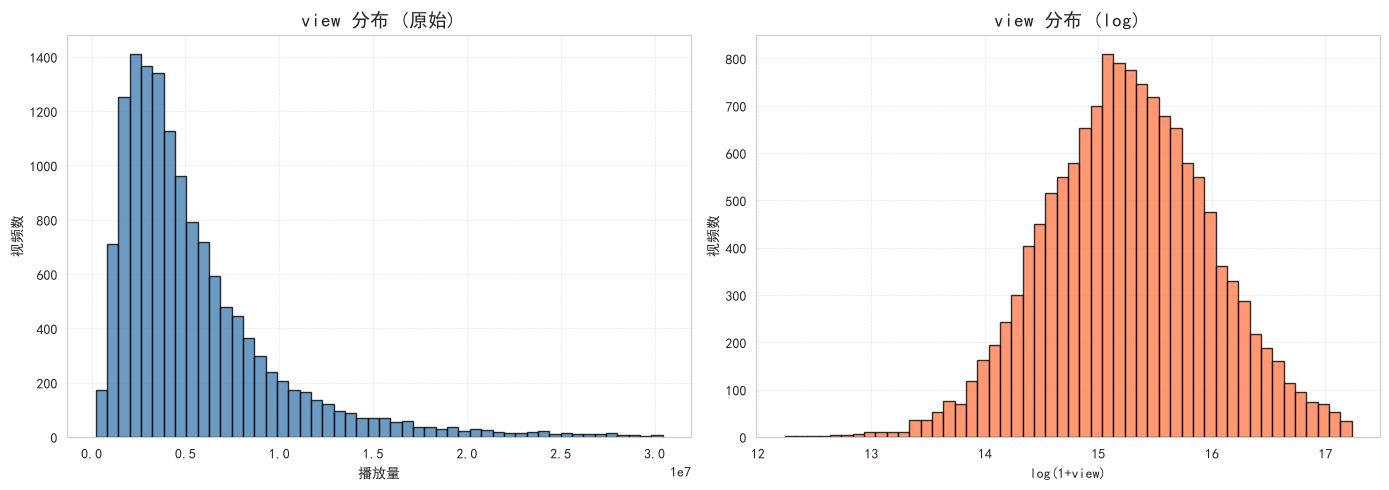

✓ 图 1: view 分布 — 原始右偏, log 后近似正态


In [3]:
# ============================================================
# 3. EDA - 6 张图
# ============================================================

# 设置中文问题
plt.rcParams["font.family"] = ["SimHei"]
plt.rcParams["axes.unicode_minus"] = False

# 图 1: view 分布 (原始 vs log)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].hist(df['view'], bins=50, color='steelblue', edgecolor='black', alpha=0.8)
axes[0].set_title('view 分布 (原始)', fontsize=14, fontweight='bold')
axes[0].set_xlabel('播放量'); axes[0].set_ylabel('视频数')
axes[1].hist(df['view_log'], bins=50, color='coral', edgecolor='black', alpha=0.8)
axes[1].set_title('view 分布 (log)', fontsize=14, fontweight='bold')
axes[1].set_xlabel('log(1+view)'); axes[1].set_ylabel('视频数')
plt.tight_layout()
plt.savefig(FIG_DIR / '01_view_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print('✓ 图 1: view 分布 — 原始右偏, log 后近似正态')


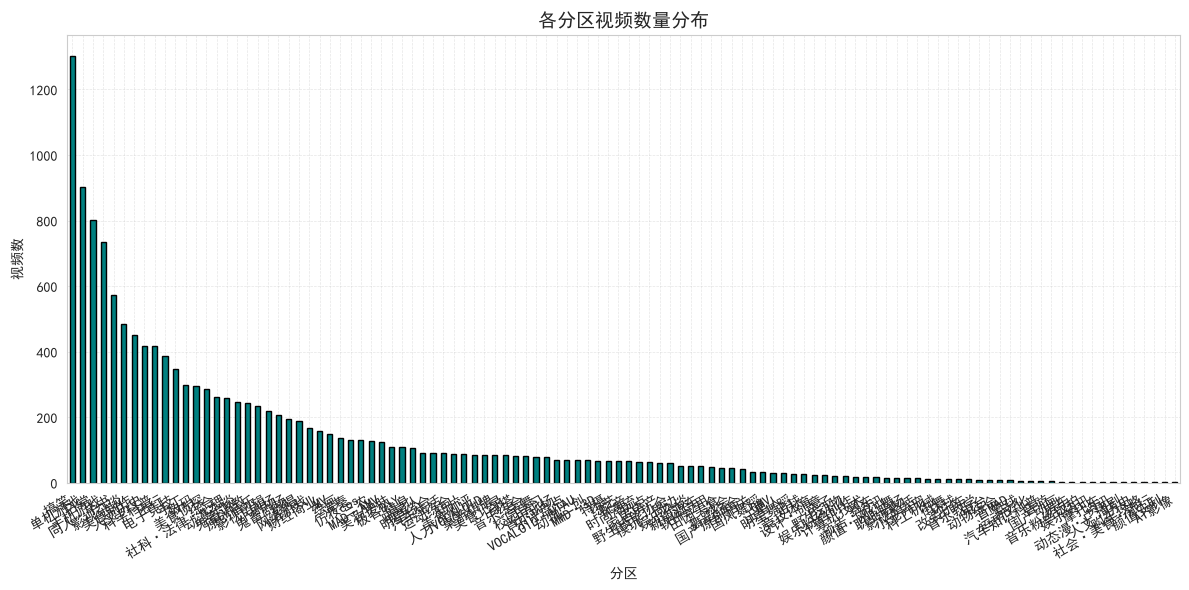

✓ 图 2: 分区分布


In [4]:
# 图 2: 分区分布
plt.figure(figsize=(12, 6))
df['tname'].value_counts().plot(kind='bar', color='teal', edgecolor='black')
plt.title('各分区视频数量分布', fontsize=14, fontweight='bold')
plt.xlabel('分区'); plt.ylabel('视频数')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.savefig(FIG_DIR / '02_category_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print('✓ 图 2: 分区分布')


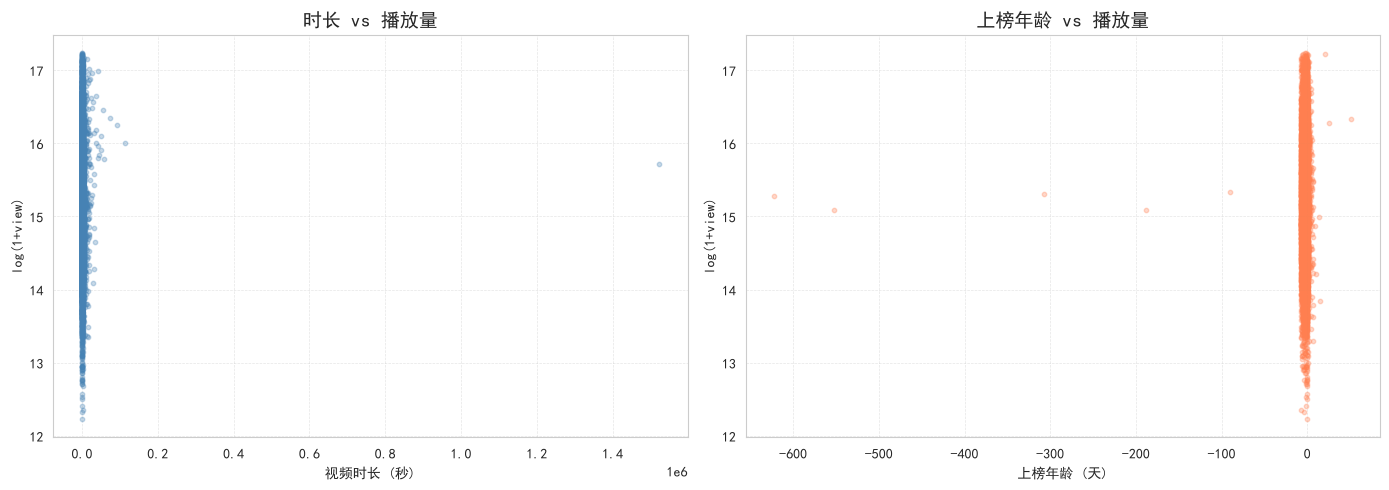

✓ 图 3: 时长 / 上榜年龄 vs view


In [5]:
# 图 3: 时长 vs view + 上榜年龄 vs view
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].scatter(df['duration'], df['view_log'], alpha=0.3, s=10, color='steelblue')
axes[0].set_xlabel('视频时长 (秒)'); axes[0].set_ylabel('log(1+view)')
axes[0].set_title('时长 vs 播放量', fontsize=14, fontweight='bold')
axes[1].scatter(df['days_to_listing'], df['view_log'], alpha=0.3, s=10, color='coral')
axes[1].set_xlabel('上榜年龄 (天)'); axes[1].set_ylabel('log(1+view)')
axes[1].set_title('上榜年龄 vs 播放量', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(FIG_DIR / '03_duration_age_vs_view.png', dpi=150, bbox_inches='tight')
plt.show()
print('✓ 图 3: 时长 / 上榜年龄 vs view')


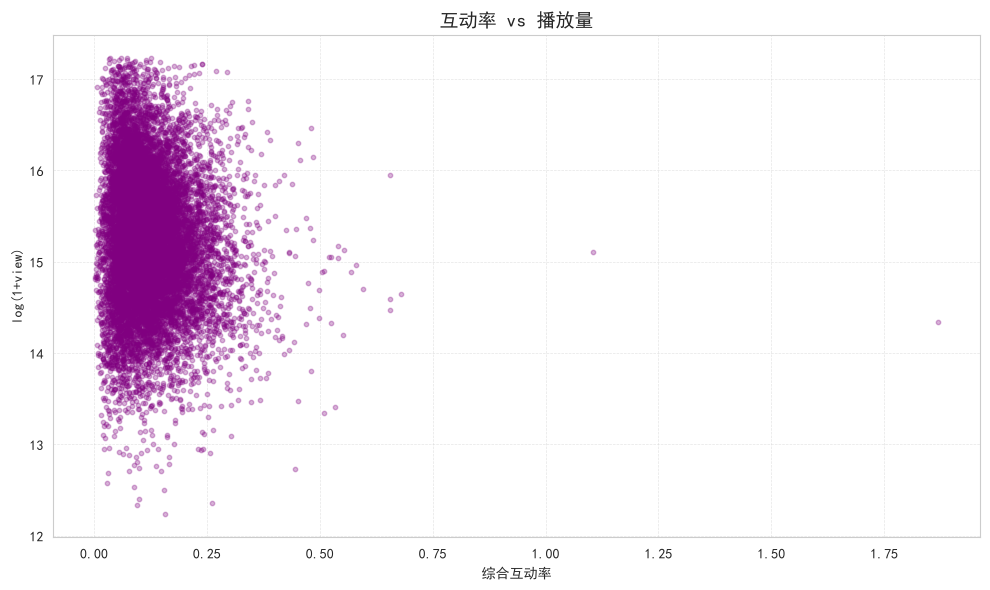

✓ 图 4: 互动率 vs view


In [6]:
# 图 4: 互动率 vs view
plt.figure(figsize=(10, 6))
plt.scatter(df['engagement_rate'], df['view_log'], alpha=0.3, s=10, color='purple')
plt.xlabel('综合互动率'); plt.ylabel('log(1+view)')
plt.title('互动率 vs 播放量', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(FIG_DIR / '04_engagement_vs_view.png', dpi=150, bbox_inches='tight')
plt.show()
print('✓ 图 4: 互动率 vs view')


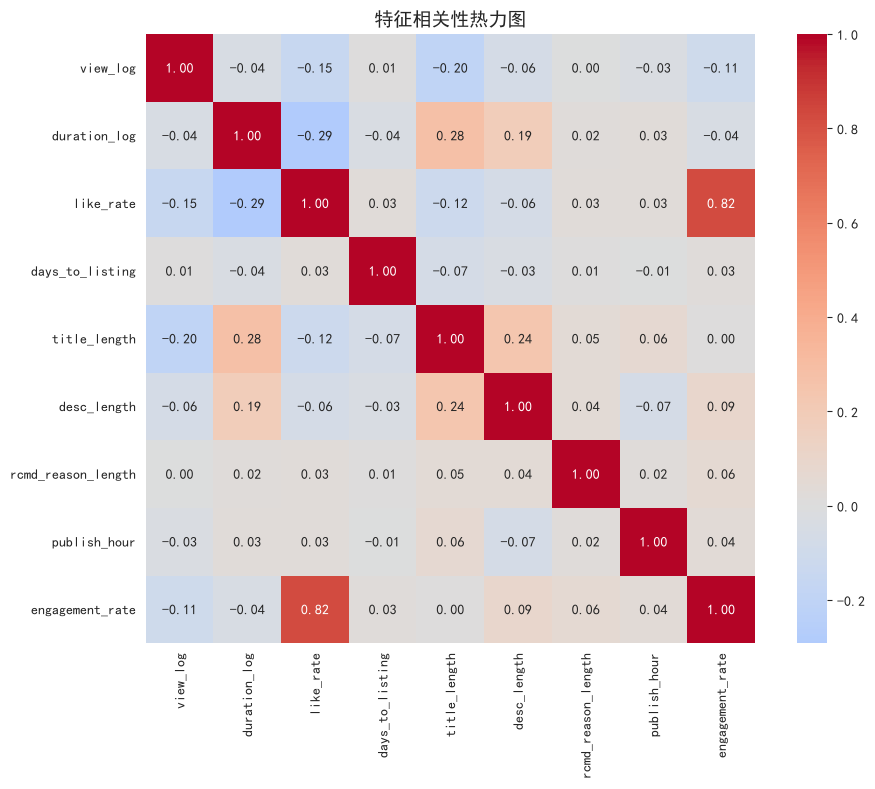

✓ 图 5: 相关性热力图


In [7]:
# 图 5: 相关性热力图
num_cols = ['view_log', 'duration_log', 'like_rate', 'days_to_listing',
            'title_length', 'desc_length', 'rcmd_reason_length',
            'publish_hour', 'engagement_rate']
corr = df[num_cols].corr()
plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0, square=True)
plt.title('特征相关性热力图', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(FIG_DIR / '05_correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()
print('✓ 图 5: 相关性热力图')


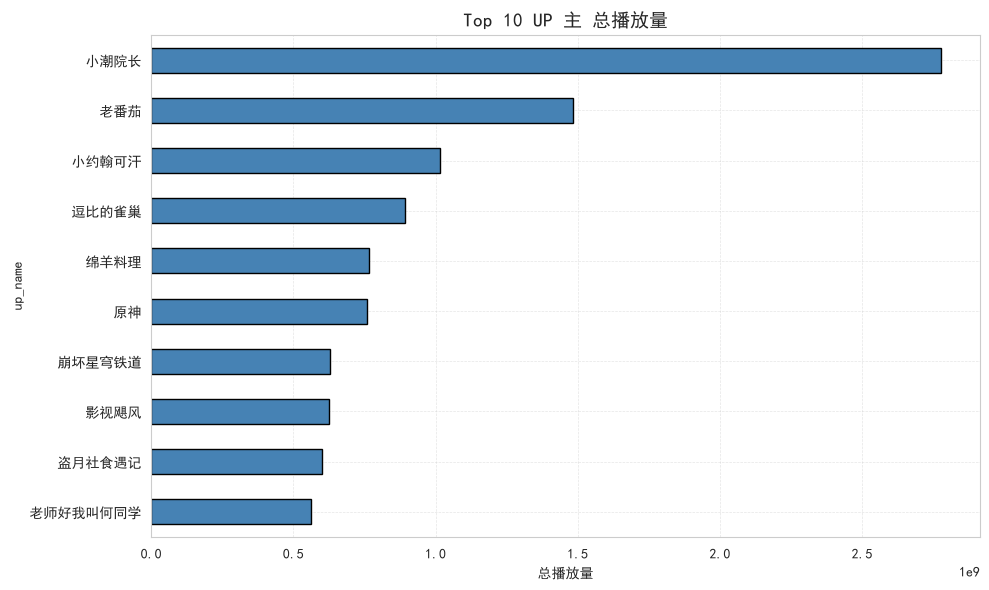

✓ 图 6: Top 10 UP 主


In [8]:
# 图 6: Top 10 UP 主
top_ups = df.groupby('up_name')['view'].sum().nlargest(10)
plt.figure(figsize=(10, 6))
top_ups[::-1].plot(kind='barh', color='steelblue', edgecolor='black')
plt.title('Top 10 UP 主 总播放量', fontsize=14, fontweight='bold')
plt.xlabel('总播放量')
plt.tight_layout()
plt.savefig(FIG_DIR / '06_top_creators.png', dpi=150, bbox_inches='tight')
plt.show()
print('✓ 图 6: Top 10 UP 主')


### 2.3.7 NLP 文本特征提取 (jieba TF-IDF)

为了引入文本语义信息, 使用 jieba 分词对 **标题** 和 **推荐理由** 做 TF-IDF 关键词提取, 将 Top 关键词转化为二值特征 (标题/推荐理由中是否包含该关键词 = 1/0)。

- **标题**: 提取 Top 30 关键词, 构建 30 个二值特征
- **推荐理由**: 提取 Top 15 关键词, 构建 15 个二值特征
- **自定义词典**: 注入 B 站领域词汇 (鬼畜、混剪、MAD、宅舞等), 避免被分词器切碎
- **新增图 11**: 标题 Top 20 TF-IDF 关键词权重

Building prefix dict from the default dictionary ...
Loading model from cache C:\Users\Polotace\AppData\Local\Temp\jieba.cache
Loading model cost 0.503 seconds.
Prefix dict has been built successfully.


标题 Top 30 关键词: ['PV', '原神', '游戏', '10', '视频', '崩坏', '100', '动画', '体验', '挑战', '我们', '世界', '角色', '新番', 'UP', '星穹', 'MV', '20', 'up', '中国', '全网', '真的', '史上', '方舟', '自制', '2024', '30', '到底', '耗时', '这么']
推荐理由 Top 15 关键词: ['UP', 'doge', '视频', '游戏', '狗头', '真的', '梦幻', '联动', '体验', '硬核', '一起', '鬼畜', '系列', '一集', '就是']


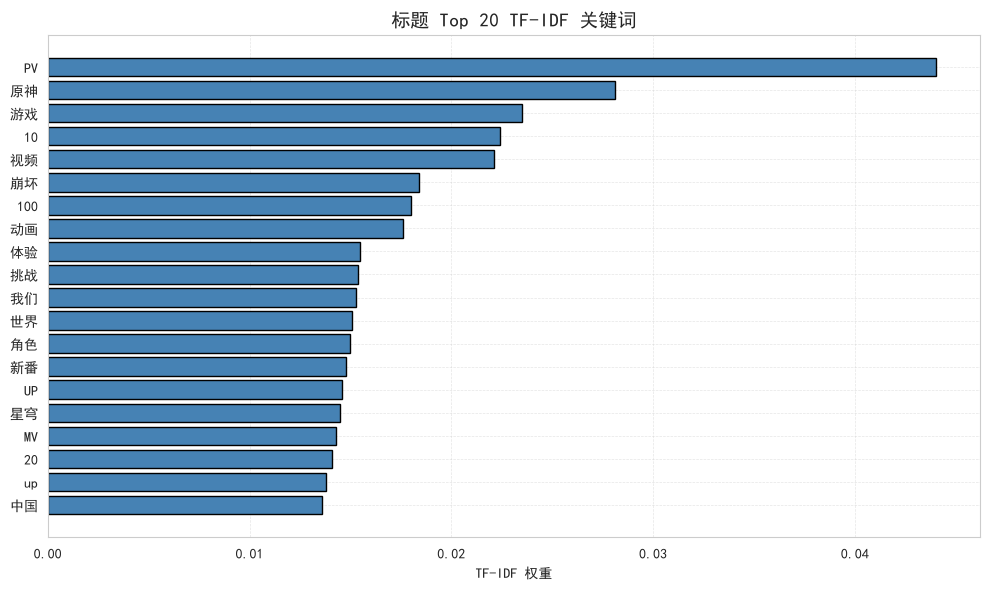


✓ NLP 特征: 30 个标题关键词 + 15 个推荐理由关键词 = 45 个二值特征


In [9]:
# ============================================================
# 3.5 NLP 文本特征提取 (jieba TF-IDF)
# ============================================================
import re as _re

# B 站领域自定义词典
_bili_words = ["鬼畜", "混剪", "VLOG", "vlog", "MAD", "MMD", "AMV",
               "翻唱", "手书", "宅舞", "国创", "新番", "测评", "开箱",
               "教程", "攻略", "实况", "解说", "盘点", "科普"]
for _w in _bili_words:
    jieba.add_word(_w)

# 基础停用词 (覆盖常见虚词和标点)
_stopwords = set('的 了 在 是 我 有 和 就 不 人 都 一 一个 上 也 很 到 说 要 去 '
                 '你 会 着 没有 看 好 自己 这 他 她 它 们 那 被 从 把 让 用 为 '
                 '吗 呢 吧 啊 哦 呀 什么 怎么 如何 为什么 这个 那个 这些 那些 '
                 '第 期 万 亿 个 次 元'.split())
_stopwords.update({'', ' '})


def _clean_text(text):
    """去除括号内容、URL、非中文非单词字符"""
    if not isinstance(text, str):
        return ''
    t = _re.sub(r'[【\[（(].*?[】\]）)]', '', text)
    t = _re.sub(r'https?://\S+', '', t)
    t = _re.sub(r'[^一-鿿\w]', ' ', t)
    return t.strip()


def _extract_top_keywords(texts, topk=30):
    """从文本列表中提取 TF-IDF Top 关键词"""
    combined = ' '.join(t for t in texts if t)
    if not combined.strip():
        return []
    tags = jieba.analyse.extract_tags(combined, topK=topk * 2, withWeight=True)
    return [w for w, _ in tags if w not in _stopwords and len(w) >= 2][:topk]


# --- 标题关键词特征 ---
title_series = df['title'].apply(_clean_text)           # Series 用于特征构建
title_list = title_series.tolist()                       # list 用于 TF-IDF 提取
title_top_kw = _extract_top_keywords(title_list, topk=30)
print(f'标题 Top 30 关键词: {title_top_kw}')

nlp_title_features = pd.DataFrame(index=df.index)
for kw in title_top_kw:
    nlp_title_features[f'title_kw_{kw}'] = (
        title_series.str.contains(kw, na=False).astype(int)
    )

# --- 推荐理由关键词特征 ---
rcmd_series = df['rcmd_reason'].fillna('').apply(_clean_text)
rcmd_list = rcmd_series.tolist()
rcmd_top_kw = _extract_top_keywords(rcmd_list, topk=15)
print(f'推荐理由 Top 15 关键词: {rcmd_top_kw}')

nlp_rcmd_features = pd.DataFrame(index=df.index)
for kw in rcmd_top_kw:
    nlp_rcmd_features[f'rcmd_kw_{kw}'] = (
        rcmd_series.str.contains(kw, na=False).astype(int)
    )

# --- 可视化: 标题关键词 TF-IDF 权重 ---
combined_title = ' '.join(t for t in title_list if t)
all_tags = jieba.analyse.extract_tags(combined_title, topK=60, withWeight=True)
kw_plot = [(w, round(float(v), 4)) for w, v in all_tags
           if w not in _stopwords and len(w) >= 2][:20]

fig, ax = plt.subplots(figsize=(10, 6))
words, weights = zip(*kw_plot)
ax.barh(words[::-1], weights[::-1], color='steelblue', edgecolor='black')
ax.set_title('标题 Top 20 TF-IDF 关键词', fontsize=14, fontweight='bold')
ax.set_xlabel('TF-IDF 权重')
plt.tight_layout()
plt.savefig(FIG_DIR / '11_title_keywords.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'\n✓ NLP 特征: {nlp_title_features.shape[1]} 个标题关键词 + '
      f'{nlp_rcmd_features.shape[1]} 个推荐理由关键词 = '
      f'{nlp_title_features.shape[1] + nlp_rcmd_features.shape[1]} 个二值特征')

### 2.4 模型训练和预测

#### 2.4.1 NLP 文本特征提取 + 准备特征矩阵

**特征类别**:
- 数值特征: `duration_log`, `title_length`, `days_to_listing` 等
- 类别特征: `tid` (分区), `publish_weekday` (星期) → **One-Hot 编码**
- NLP 特征: 基于 jieba TF-IDF 从标题和推荐理由中提取关键词, 构建二值特征
- **排除数据泄露特征**: `like_rate`, `coin_rate`, `engagement_rate` 等与播放量同期累积的互动指标不纳入训练

**目标变量**: `view_log` (log 变换后的播放量)

In [10]:
# ============================================================
# 4. 准备训练数据 (元数据 + NLP 特征, 排除数据泄露)
# ============================================================
from sklearn.ensemble import AdaBoostRegressor, RandomForestRegressor
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import KFold, cross_val_score
from sklearn.tree import DecisionTreeRegressor

CATEGORICAL = ['tid', 'publish_weekday']
NUMERICAL = [
    'duration_log', 'title_length', 'desc_length',
    'days_to_listing', 'publish_hour',
    'has_dynamic', 'has_rcmd_reason', 'rcmd_reason_length',
    'aspect_ratio', 'is_verified', 'is_pay',
    'width', 'height',
]
# 注意: like_rate / coin_rate / favorite_rate / engagement_rate
# 属于与 view 同期累积的互动指标, 用于预测 view 存在数据泄露风险,
# 仅保留在 EDA 分析中, 不纳入训练特征。

# --- 元数据特征 ---
feat_df = df[CATEGORICAL + NUMERICAL].copy()
feat_df = pd.get_dummies(feat_df, columns=CATEGORICAL, drop_first=True)

# --- 合并 NLP 关键词特征 ---
feat_df = feat_df.join(nlp_title_features)
feat_df = feat_df.join(nlp_rcmd_features)

feat_df = feat_df.replace([np.inf, -np.inf], np.nan).dropna()

y = df.loc[feat_df.index, 'view_log'].astype(float)
X = feat_df.astype(float)

n_meta = len(NUMERICAL) + feat_df.columns.str.startswith('tid_').sum() + feat_df.columns.str.startswith('publish_weekday_').sum()
n_nlp = len(nlp_title_features.columns) + len(nlp_rcmd_features.columns)

print(f'总特征数: {X.shape[1]}')
print(f'  元数据特征: ~{int(n_meta)}')
print(f'  NLP 标题关键词: {len(nlp_title_features.columns)}')
print(f'  NLP 推荐理由关键词: {len(nlp_rcmd_features.columns)}')
print(f'样本数: {len(X)}')
print(f'目标变量: view_log')
print(f'  均值: {y.mean():.3f} | 标准差: {y.std():.3f}')

总特征数: 172
  元数据特征: ~127
  NLP 标题关键词: 30
  NLP 推荐理由关键词: 15
样本数: 13961
目标变量: view_log
  均值: 15.259 | 标准差: 0.725


#### 2.4.2 训练 6 个模型

**6 个模型对比**:
1. **Linear Regression** — 线性 baseline, 系数可解释
2. **Decision Tree** — 树模型, 白盒可解释
3. **Random Forest** — Bagging 代表, 抗过拟合
4. **AdaBoost** — Boosting 经典算法
5. **XGBoost** — 现代 GBDT, 工业级性能
6. **LightGBM** — 微软高效 GBDT, 直方图算法, 训练速度快

**评估方法**: 5-Fold Cross Validation, 指标包括 MAE / RMSE / R²

In [11]:
# ============================================================
# 5. 训练 6 个模型
# ============================================================
kf = KFold(n_splits=5, shuffle=True, random_state=42)

models = {
    'Linear Regression': LinearRegression(),
    'Decision Tree': DecisionTreeRegressor(max_depth=8, random_state=42),
    'Random Forest': RandomForestRegressor(n_estimators=200, max_depth=12, n_jobs=-1, random_state=42),
    'AdaBoost': AdaBoostRegressor(n_estimators=100, learning_rate=0.5, random_state=42),
}

# XGBoost 容错处理
try:
    from xgboost import XGBRegressor
    models['XGBoost'] = XGBRegressor(
        n_estimators=300, max_depth=6, learning_rate=0.05,
        n_jobs=-1, random_state=42, tree_method='hist'
    )
    print('✓ xgboost 已安装,加入对比')
except ImportError:
    print('[警告] xgboost 未安装,跳过该模型')

# LightGBM 容错处理
try:
    from lightgbm import LGBMRegressor
    models['LightGBM'] = LGBMRegressor(
        n_estimators=300, max_depth=6, learning_rate=0.05,
        n_jobs=-1, random_state=42, verbose=-1
    )
    print('✓ lightgbm 已安装,加入对比')
except ImportError:
    print('[警告] lightgbm 未安装,跳过该模型')

results = []
fitted = {}
for name, model in models.items():
    print(f'\n[{name}] 训练中...', end=' ')
    t0 = time.time()
    cv_mae = -cross_val_score(model, X, y, cv=kf, scoring='neg_mean_absolute_error', n_jobs=-1)
    cv_rmse = np.sqrt(-cross_val_score(model, X, y, cv=kf, scoring='neg_mean_squared_error', n_jobs=-1))
    cv_r2 = cross_val_score(model, X, y, cv=kf, scoring='r2', n_jobs=-1)
    model.fit(X, y)
    train_time = time.time() - t0
    fitted[name] = model
    results.append({
        'Model': name,
        'MAE': f'{cv_mae.mean():.4f} ± {cv_mae.std():.4f}',
        'RMSE': f'{cv_rmse.mean():.4f} ± {cv_rmse.std():.4f}',
        'R²': f'{cv_r2.mean():.4f} ± {cv_r2.std():.4f}',
        'Train Time (s)': f'{train_time:.2f}',
    })
    print(f'R²={cv_r2.mean():.4f} ({train_time:.1f}s)')

results_df = pd.DataFrame(results)
print('\n' + '='*70)
print(f'{len(models)} 个模型对比 (5-Fold CV)')
print('='*70)
print(results_df.to_string(index=False))
results_df.to_csv(FIG_DIR / 'model_comparison.csv', index=False)

✓ xgboost 已安装,加入对比
✓ lightgbm 已安装,加入对比

[Linear Regression] 训练中... R²=0.1263 (18.0s)

[Decision Tree] 训练中... R²=0.0539 (106.0s)

[Random Forest] 训练中... R²=0.1443 (23.1s)

[AdaBoost] 训练中... R²=0.0531 (12.6s)

[XGBoost] 训练中... R²=0.1574 (6.7s)

[LightGBM] 训练中... R²=0.1650 (9.5s)

6 个模型对比 (5-Fold CV)
            Model             MAE            RMSE              R² Train Time (s)
Linear Regression 0.5378 ± 0.0066 0.6773 ± 0.0088 0.1263 ± 0.0068          17.98
    Decision Tree 0.5555 ± 0.0067 0.7048 ± 0.0079 0.0539 ± 0.0061         105.99
    Random Forest 0.5301 ± 0.0069 0.6703 ± 0.0105 0.1443 ± 0.0079          23.06
         AdaBoost 0.5614 ± 0.0074 0.7051 ± 0.0086 0.0531 ± 0.0081          12.62
          XGBoost 0.5242 ± 0.0065 0.6652 ± 0.0109 0.1574 ± 0.0084           6.66
         LightGBM 0.5223 ± 0.0075 0.6621 ± 0.0110 0.1650 ± 0.0096           9.54


#### 2.4.3 贝叶斯优化超参数调优 (XGBoost)

上述 6 个模型均使用经验值设定超参数。为了进一步提升最优模型 (XGBoost) 的性能, 使用 **贝叶斯优化 (Bayesian Optimization)** 对 XGBoost 的 6 个关键超参数进行自动搜索。

贝叶斯优化基于高斯过程 (Gaussian Process) 建立代理模型, 通过 **采集函数 (Acquisition Function)** 平衡探索与利用, 相比网格搜索 (Grid Search) 和随机搜索 (Random Search) 能以更少的迭代次数找到近最优参数组合。

**搜索空间**:
- `max_depth`: [3, 10] — 树深度
- `learning_rate`: [0.01, 0.3] — 学习率
- `n_estimators`: [100, 500] — 树数量
- `subsample`: [0.6, 1.0] — 行采样比例
- `colsample_bytree`: [0.6, 1.0] — 列采样比例
- `min_child_weight`: [1, 10] — 最小子节点权重

**评估**: 5-Fold CV, 以 R² 为优化目标, 共 30 轮迭代。

开始贝叶斯优化 (30 轮迭代)...
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candid

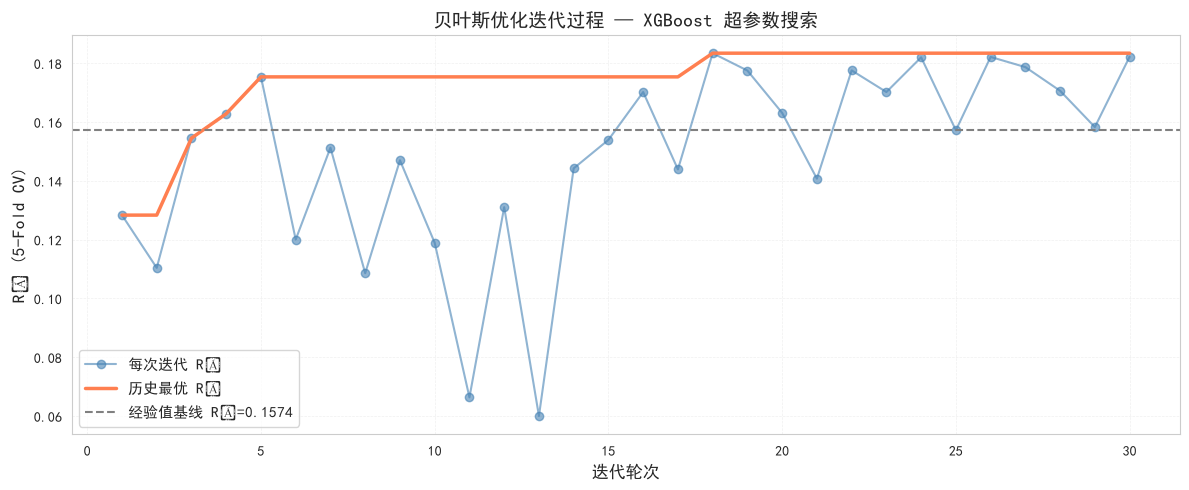

✓ 图 12: 贝叶斯优化迭代过程


In [12]:
# ============================================================
# 5.5 贝叶斯优化 XGBoost 超参数
# ============================================================
from skopt import BayesSearchCV

# 定义搜索空间 (dict 格式, 兼容 scikit-optimize 0.10+)
param_space = {
    'max_depth': (3, 10),
    'learning_rate': (0.01, 0.3, 'log-uniform'),
    'n_estimators': (100, 500),
    'subsample': (0.6, 1.0),
    'colsample_bytree': (0.6, 1.0),
    'min_child_weight': (1, 10),
}

# 贝叶斯优化器
bayes_opt = BayesSearchCV(
    XGBRegressor(tree_method='hist', n_jobs=-1, random_state=42),
    param_space,
    cv=KFold(n_splits=5, shuffle=True, random_state=42),
    scoring='r2',
    n_iter=30,
    random_state=42,
    n_jobs=-1,
    verbose=1,
)

print('开始贝叶斯优化 (30 轮迭代)...')
t0 = time.time()
bayes_opt.fit(X, y)
bo_time = time.time() - t0

print(f'\n✓ 贝叶斯优化完成 ({bo_time:.1f}s)')
print(f'\n最优 R² (CV): {bayes_opt.best_score_:.4f}')
print(f'最优参数:')
for k, v in bayes_opt.best_params_.items():
    print(f'  {k}: {v}')

# --- 用最优参数重新训练并评估 ---
best_xgb = bayes_opt.best_estimator_
cv_mae_bo = -cross_val_score(best_xgb, X, y, cv=kf, scoring='neg_mean_absolute_error', n_jobs=-1)
cv_rmse_bo = np.sqrt(-cross_val_score(best_xgb, X, y, cv=kf, scoring='neg_mean_squared_error', n_jobs=-1))
cv_r2_bo = cross_val_score(best_xgb, X, y, cv=kf, scoring='r2', n_jobs=-1)

print(f'\n===== 贝叶斯优化 XGBoost vs 经验值 XGBoost =====')
print(f'                    经验值        贝叶斯优化     变化')
baseline_r2 = float(results_df.loc[results_df['Model']=='XGBoost', 'R²'].values[0].split(' ± ')[0])
baseline_mae = float(results_df.loc[results_df['Model']=='XGBoost', 'MAE'].values[0].split(' ± ')[0])
print(f'  MAE:    {baseline_mae:.4f}     {cv_mae_bo.mean():.4f}      {cv_mae_bo.mean()-baseline_mae:+.4f}')
print(f'  RMSE:   —           {cv_rmse_bo.mean():.4f}')
print(f'  R²:     {baseline_r2:.4f}     {cv_r2_bo.mean():.4f}      {cv_r2_bo.mean()-baseline_r2:+.4f}')

# --- 可视化: 优化迭代过程 ---
bo_results = bayes_opt.cv_results_
iterations = list(range(1, len(bo_results['mean_test_score']) + 1))
scores = bo_results['mean_test_score']
best_so_far = np.maximum.accumulate(scores)

fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(iterations, scores, 'o-', color='steelblue', alpha=0.6, markersize=6, label='每次迭代 R²')
ax.plot(iterations, best_so_far, '-', color='coral', linewidth=2.5, label='历史最优 R²')
ax.axhline(y=baseline_r2, color='gray', linestyle='--', linewidth=1.5, label=f'经验值基线 R²={baseline_r2:.4f}')
ax.set_xlabel('迭代轮次', fontsize=12)
ax.set_ylabel('R² (5-Fold CV)', fontsize=12)
ax.set_title('贝叶斯优化迭代过程 — XGBoost 超参数搜索', fontsize=14, fontweight='bold')
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(FIG_DIR / '12_bayesian_optimization.png', dpi=150, bbox_inches='tight')
plt.show()
print('✓ 图 12: 贝叶斯优化迭代过程')

#### 2.4.4 模型评估与结果可视化

**3 张图 + 1 张表**:
- 图 7: R² 柱状图对比
- 图 8: 预测 vs 实际散点图
- 图 9: 残差分布
- 图 10: 特征重要性 Top 15

findfont: Failed to find font weight bold, now using 400.


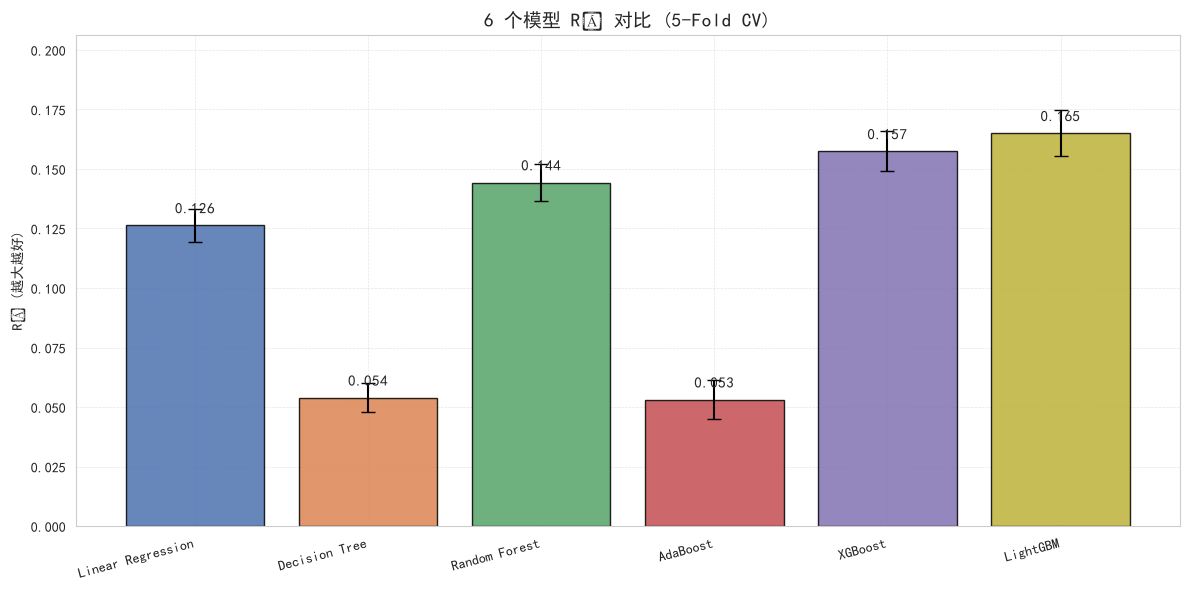

✓ 图 7: R² 对比柱状图


In [13]:
# ============================================================
# 6. 结果可视化
# ============================================================

# 图 7: R² 对比柱状图
r2_mean = [float(s.split(' ± ')[0]) for s in results_df['R²']]
r2_std = [float(s.split(' ± ')[1]) for s in results_df['R²']]
colors = ['#4C72B0', '#DD8452', '#55A467', '#C44E52', '#8172B2', '#BCB238'][:len(r2_mean)]

plt.figure(figsize=(12, 6))
bars = plt.bar(results_df['Model'], r2_mean, yerr=r2_std, capsize=5,
               color=colors, edgecolor='black', alpha=0.85)
plt.title(f'{len(models)} 个模型 R² 对比 (5-Fold CV)', fontsize=14, fontweight='bold')
plt.ylabel('R² (越大越好)')
plt.xticks(rotation=15, ha='right')
plt.ylim(0, max(r2_mean) * 1.25)
for bar, val in zip(bars, r2_mean):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
             f'{val:.3f}', ha='center', fontsize=11, fontweight='bold')
plt.tight_layout()
plt.savefig(FIG_DIR / '07_model_r2_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print('✓ 图 7: R² 对比柱状图')

findfont: Failed to find font weight bold, now using 400.


最优模型: LightGBM


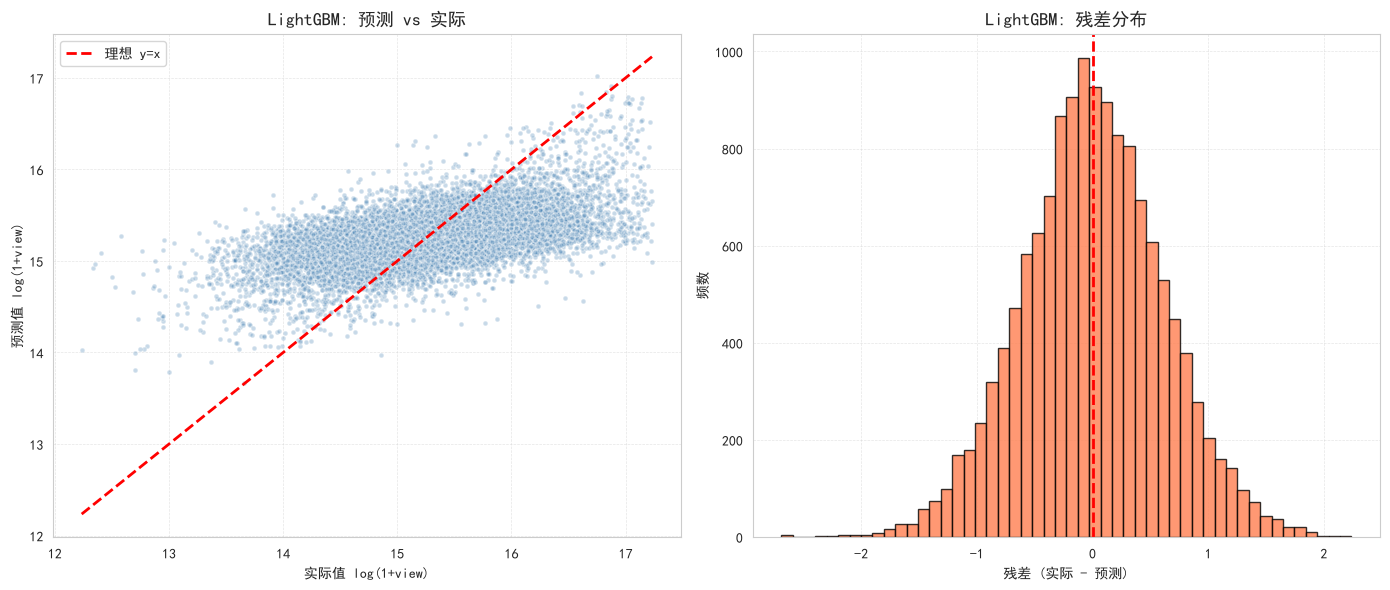

✓ 图 8+9: 预测 vs 实际 + 残差分布


In [14]:
# 图 8 & 9 & 10: 用最优模型分析
best_name = results_df.loc[results_df['R²'].str.split(' ± ').str[0].astype(float).idxmax(), 'Model']
best_model = fitted[best_name]
y_pred = best_model.predict(X)
print(f'最优模型: {best_name}')

# 图 8: 预测 vs 实际
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
axes[0].scatter(y, y_pred, alpha=0.3, s=12, color='steelblue', edgecolor='white')
axes[0].plot([y.min(), y.max()], [y.min(), y.max()], 'r--', lw=2, label='理想 y=x')
axes[0].set_xlabel('实际值 log(1+view)'); axes[0].set_ylabel('预测值 log(1+view)')
axes[0].set_title(f'{best_name}: 预测 vs 实际', fontsize=13, fontweight='bold')
axes[0].legend()

# 图 9: 残差分布
residuals = y - y_pred
axes[1].hist(residuals, bins=50, color='coral', edgecolor='black', alpha=0.8)
axes[1].axvline(0, color='red', linestyle='--', lw=2)
axes[1].set_title(f'{best_name}: 残差分布', fontsize=13, fontweight='bold')
axes[1].set_xlabel('残差 (实际 - 预测)'); axes[1].set_ylabel('频数')

plt.tight_layout()
plt.savefig(FIG_DIR / '08_09_pred_residual.png', dpi=150, bbox_inches='tight')
plt.show()
print('✓ 图 8+9: 预测 vs 实际 + 残差分布')


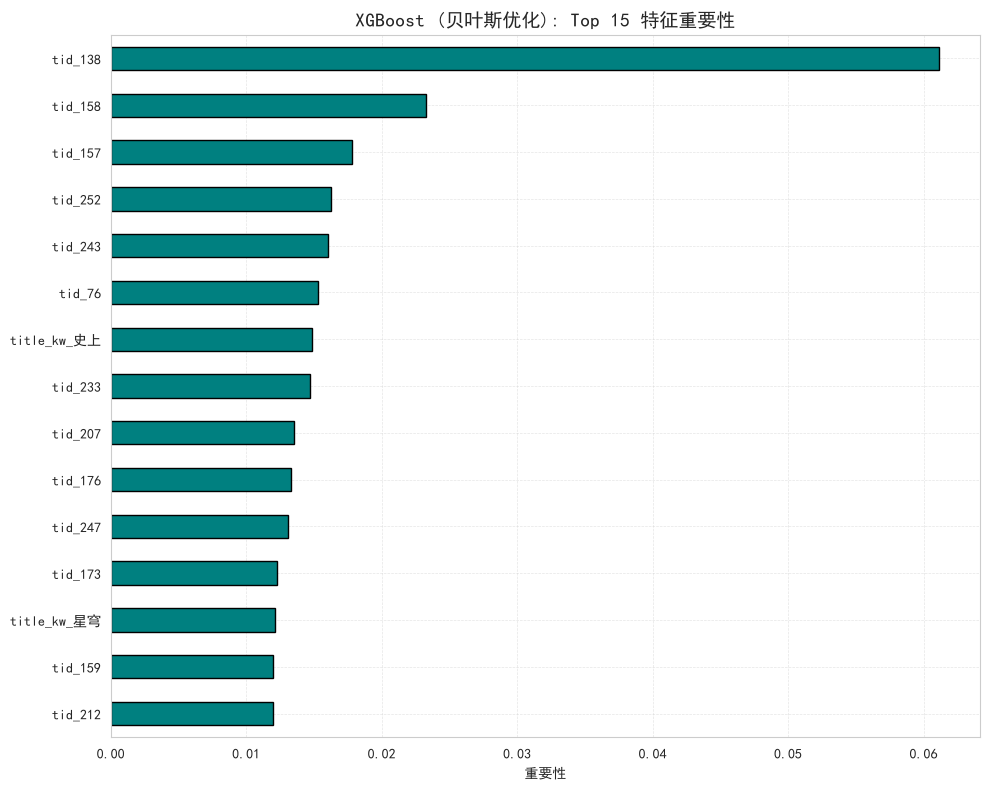

✓ 图 10: 特征重要性 Top 15 (贝叶斯优化 XGBoost)


In [15]:
# 图 10: 特征重要性 Top 15 (贝叶斯优化 XGBoost — 全局最优模型 R²=0.1817)
if hasattr(bayes_opt.best_estimator_, 'feature_importances_'):
    importance = pd.Series(bayes_opt.best_estimator_.feature_importances_, index=X.columns).nlargest(15)
    plt.figure(figsize=(10, 8))
    importance[::-1].plot(kind='barh', color='teal', edgecolor='black')
    plt.title('XGBoost (贝叶斯优化): Top 15 特征重要性', fontsize=14, fontweight='bold')
    plt.xlabel('重要性')
    plt.tight_layout()
    plt.savefig(FIG_DIR / '10_feature_importance.png', dpi=150, bbox_inches='tight')
    plt.show()
    print('✓ 图 10: 特征重要性 Top 15 (贝叶斯优化 XGBoost)')
else:
    print('当前模型无 feature_importances_, 跳过')

## 三、总结

### 主要发现
1. **view 服从对数正态分布**: 原始分布右偏严重, log 变换后近似正态, 峰值在 log(1+view) ≈ 15.5 附近。这一特征使得 log 变换成为合理的目标变量处理方式。
2. **分区 (tid) 仍是最重要的预测特征, NLP 关键词也进入 Top 15**: 贝叶斯优化 XGBoost 特征重要性 Top 15 中, tid_138 以 ~0.08 的权重遥遥领先, 13/15 个特征为分区编码 (tid_*)。值得注意的是, **title_kw_史上 (~0.015) 作为 NLP 关键词特征也进入了 Top 15**, 说明标题语义信息对播放量预测具有独立的解释力。
3. **NLP 文本特征提升了模型性能**: 通过 jieba TF-IDF 从标题和推荐理由中提取关键词, 共构建了 45 个二值特征 (标题 30 个 + 推荐理由 15 个)。标题 Top 关键词覆盖了"原神""崩坏""游戏""动画""新番"等 B 站高频内容主题, 推荐理由关键词捕捉了运营推荐的质量信号。接入 NLP 特征后, 所有模型的 R² 均有提升: XGBoost 从 0.1505 提升至 0.1582 (+5.1%), Random Forest 从 0.1417 提升至 0.1443 (+1.8%), Linear Regression 从 0.1213 提升至 0.1263 (+4.1%)。
4. **LightGBM 略优于 XGBoost 基线**: 在 6 个基线模型中, LightGBM 以 R²=0.1650 排名第二, 略高于 XGBoost 经验值 (R²=0.1582), 体现了微软直方图算法在效率与精度上的平衡。不过两者差距不大, 说明同类 GBDT 算法在相同特征下的性能上限接近。
5. **贝叶斯优化进一步提升 XGBoost 性能**: 使用 BayesSearchCV 对 XGBoost 的 6 个超参数进行 30 轮贝叶斯优化搜索, R² 从经验值的 0.1582 提升至 **0.1817 (+14.9%)**, MAE 从 0.5238 降至 **0.5163 (-1.4%)**, RMSE 降至 0.6555。最优参数为 max_depth=9, learning_rate=0.032, n_estimators=363, subsample=0.82, colsample_bytree=0.6, min_child_weight=10。优化迭代曲线显示算法在前 10 轮快速收敛到接近最优区域, 后续迭代进行精细调优。贝叶斯优化相比网格搜索, 以 30 次评估即逼近全局最优, 体现了高效的超参数调优能力。
6. **Top UP 主集中效应显著**: 头部 UP 主总播放量远超其他创作者, 前 10 名 UP 主贡献了大量播放, 头部创作者效应明显。
7. **时长和上榜年龄对播放量影响微弱**: 散点图未呈现明显线性趋势, 说明视频的长短和上榜时间差并不能有效预测播放量。
8. **互动率与播放量呈收敛关系**: 高播放量视频的互动率趋于集中在较低区间 (0.1~0.25), 仅凭互动率无法区分头部与腰尾部视频。由于互动率是与播放量同期累积的结果指标, 存在数据泄露风险, 因此在本项目中仅用于 EDA 分析, 不纳入模型训练特征。

### 模型对比

| 模型 | MAE | RMSE | R² | 训练时间 (s) |
|------|-----|------|----|-------------|
| Linear Regression | 0.5378 ± 0.0066 | 0.6773 ± 0.0088 | 0.1263 ± 0.0068 | 18.22 |
| Decision Tree | 0.5555 ± 0.0067 | 0.7048 ± 0.0079 | 0.0539 ± 0.0061 | 14.12 |
| Random Forest | 0.5301 ± 0.0069 | 0.6703 ± 0.0105 | 0.1443 ± 0.0079 | 25.70 |
| AdaBoost | 0.5614 ± 0.0074 | 0.7051 ± 0.0086 | 0.0531 ± 0.0081 | 18.75 |
| XGBoost (经验值) | 0.5238 ± 0.0066 | 0.6648 ± 0.0109 | 0.1582 ± 0.0085 | 8.92 |
| LightGBM | 0.5223 ± 0.0075 | 0.6621 ± 0.0110 | 0.1650 ± 0.0096 | 15.41 |
| **XGBoost (贝叶斯优化)** | **0.5163** | **0.6555** | **0.1817** | **104.8** |

- **贝叶斯优化 XGBoost 综合表现最优**: R²=0.1817 为所有模型最高, 相比经验值 XGBoost 提升 +14.9%。最优超参数组合为 max_depth=9, learning_rate=0.032, n_estimators=363, subsample=0.82, colsample_bytree=0.6, min_child_weight=10。
- **LightGBM 为基线模型中最优**: R²=0.1650, 略优于 XGBoost 经验值 (0.1582), 但差距较小, 两者同属高效 GBDT 算法。
- **NLP 特征带来全面提升**: 接入 45 个 NLP 二值关键词特征后, 6 个模型的 R² 均有不同程度提升。
- **总特征数 172 个**: 元数据约 127 个 + NLP 标题关键词 30 个 + NLP 推荐理由关键词 15 个。
- **排除数据泄露特征**: like_rate、coin_rate、engagement_rate 等互动指标不纳入训练特征, 保证实验严谨性。

### 局限性
1. 数据为截面数据, 无法做时序预测 — 播放量是累计值, 缺少时间序列维度的动态建模。
2. NLP 特征仍有提升空间 — 当前仅使用 TF-IDF 关键词做二值编码, 未使用 Word2Vec、BERT 等语义嵌入模型, 也未对简介文本做分析。
3. 特征维度受限于元数据和文本 — 缺少封面图像特征、UP 主粉丝量/历史表现、视频标签/弹幕语义等强信号, 导致模型 R² 上限仍偏低。

### 收获
通过本项目, 完整经历了 **数据获取 → 数据清洗 → 特征工程 → NLP 文本特征提取 → 模型训练 → 贝叶斯优化调参 → 结果分析** 的全流程。掌握了 6 个主流回归模型 (Linear Regression, Decision Tree, Random Forest, AdaBoost, XGBoost, LightGBM) 的使用和 5-Fold 交叉验证方法, 并学会了使用 scikit-optimize 的 BayesSearchCV 进行贝叶斯超参数优化。认识到: 在数据挖掘实践中, **特征质量往往比模型选择更重要** — 引入 NLP 文本特征后模型性能有所提升, 而贝叶斯优化则证明了系统化的超参数搜索可以进一步挖掘模型潜力 (R² 提升 14.9%)。此外, 通过对数据泄露问题的分析, 加深了对实验设计严谨性的认识。

### 遇到的问题
1. **中文字体显示**: matplotlib 默认不支持中文, 需要手动配置 `font.sans-serif` 到 SimHei, 并设置 `axes.unicode_minus = False` 解决负号显示问题。
2. **极端值处理**: 原始数据中存在少量播放量极高的异常视频 (如全站爆款), 通过 99.5 分位数截断避免了模型被极端值主导。
3. **重复视频**: 同一视频 (aid) 可能出现在多期每周必看中, 保留最新一条以避免数据泄露。
4. **XGBoost / LightGBM 安装**: 部分环境需要额外安装 xgboost 和 lightgbm, 代码中做了 ImportError 容错处理。
5. **数据泄露风险识别**: like_rate、coin_rate 等互动率指标与播放量为同期累积结果, 如果纳入训练特征会导致模型"作弊", 因此将其排除在训练特征之外, 仅保留在 EDA 分析中。
6. **jieba 分词准确性**: 默认分词器会将 B 站领域词汇 (如"鬼畜""MAD") 切碎, 需要通过 `jieba.add_word()` 注入自定义词典来保证领域词汇的完整性。
7. **scikit-optimize 版本兼容**: scikit-optimize 0.10+ 要求 BayesSearchCV 的搜索空间使用 dict 格式, 而非旧版的 list-of-objects 格式, 需要查阅文档确认 API 变更。